<a href="https://colab.research.google.com/github/tasninkhanlamha/SkillMorph/blob/main/Android_Ransomware_Detection_new%20datasetbinary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Android Ransomware Detection Detection**

## **Font family setup**

In [ ]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [ ]:
#Dataset Link:

## **Importing Dataset**

In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/Skill-Morph/android_ransomware_preprocessed.csv")

## **Basic Information**

In [ ]:
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,53,17,24707,1,1,48.0,199.0,48.0,48.0,48.000000,...,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392030,123,17,81388,1,1,48.0,48.0,48.0,48.0,48.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392031,53,17,61591,1,1,39.0,98.0,39.0,39.0,39.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392032,53,17,24831,1,1,36.0,153.0,36.0,36.0,36.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10


In [ ]:
df.shape

(392034, 79)

In [ ]:
df['Label'].value_counts()

,count
Label,
8,54161
6,46082
3,44555
0,43091
7,39859
1,39551
9,36340
10,32701
2,25672


## **Data Samples per Class**

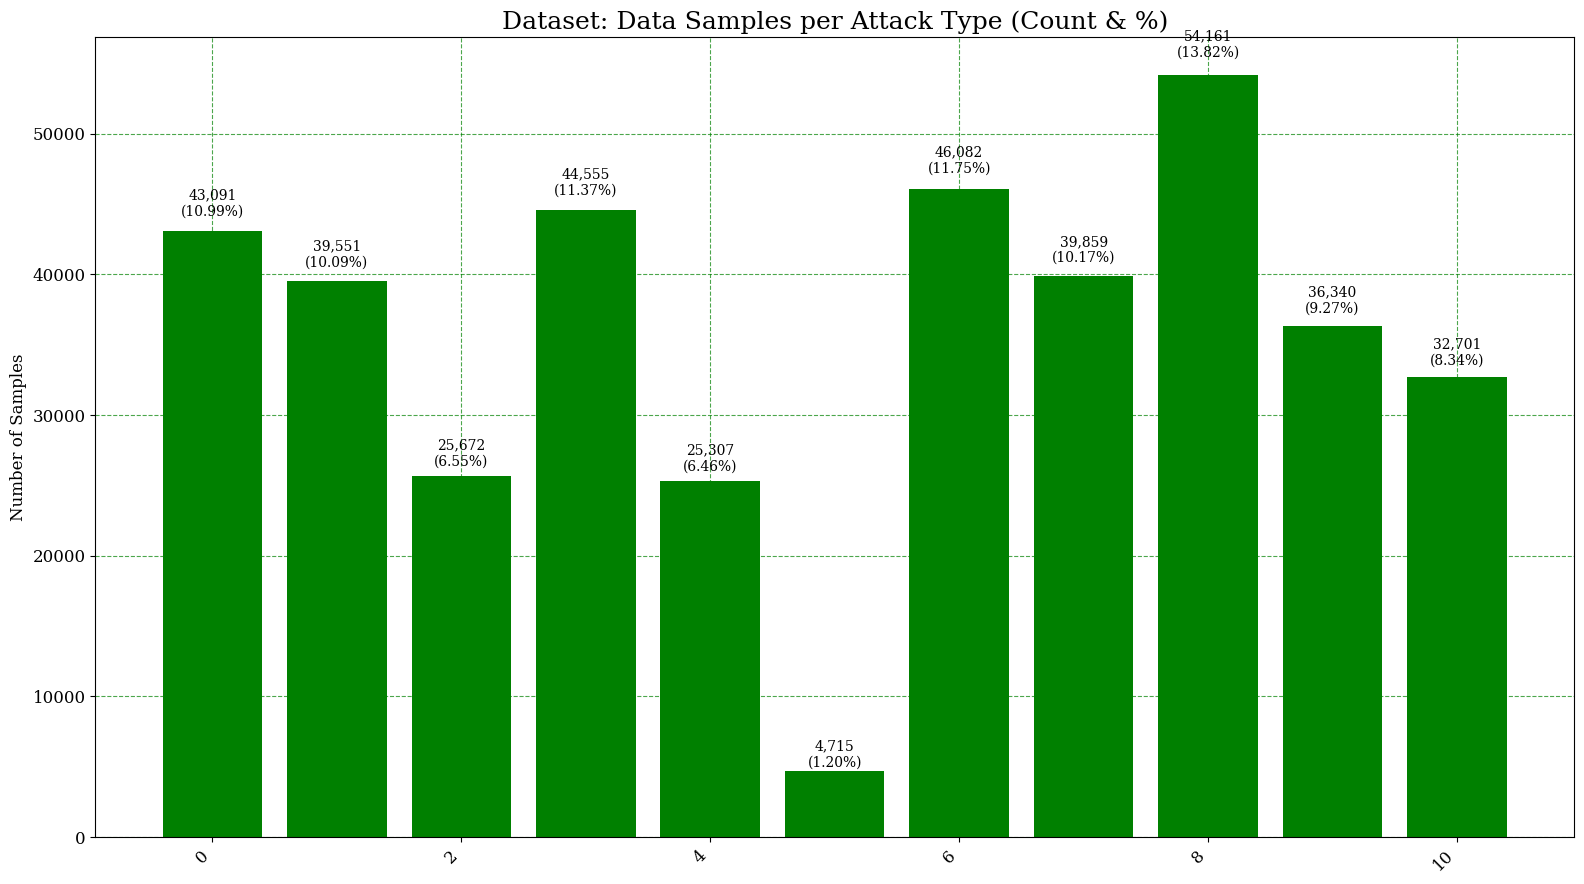

In [ ]:
import matplotlib.pyplot as plt

# Count samples and percentages
label_counts = df['Label'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Set up the plot
plt.figure(figsize=(16, 9))
bars = plt.bar(label_counts.index, label_counts.values, color='green')  # Bar color set to green

# Add count and percentage text above each bar
for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{label_counts.values[idx]:,}'
    percent_text = f'({label_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.02*height,
        f'{count_text}\n{percent_text}',
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
plt.title('Dataset: Data Samples per Attack Type (Count & %)', fontsize=18)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7, color='green')  # Grid color set to green
# Enable both horizontal and vertical green grid lines
plt.grid(axis='both', linestyle='--', alpha=0.7, color='green')

plt.tight_layout()

# Show plot
plt.show()


## **Handle Missing Values**

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Only show columns with missing values

print("Columns with Missing Values:\n", missing_values)


# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values in numerical columns with median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

if len(categorical_cols) > 0 and not df[categorical_cols].mode().empty:
    df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])
else:
    print("Nothing to fill in categorical columns.")

# Verify if missing values are filled
print("Missing values after filling:\n", df.isnull().sum().sum())  # Should be 0 if all missing values are handled



Columns with Missing Values:
 Series([], dtype: int64)
Nothing to fill in categorical columns.
Missing values after filling:
 0


In [ ]:
# Print the names of the features (columns)
print(df.columns)

Index(['Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       

## **Data Preprocessing**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Clean Infinity and Garbage Values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(to_replace=[r'^(-?\d+\.\d+e\+\d+|-?\d+\.\d+e-\d+|-?\d+\.\d+|-?\d+)$', r'^(-?\d+)$'], value=np.nan, regex=True)
df.dropna(inplace=True)

# 2. Separate Numerical Columns (excluding 'Label')
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
num_cols = num_cols.difference(['Label'])

# 3. Feature Scaling (only for Numerical Features)
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# 4. Separate Categorical Columns (excluding 'Label')
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.difference(['Label'])

# 5. Categorical Encoding (ensuring all columns are strings)
df[cat_cols] = df[cat_cols].astype(str)
encoder = LabelEncoder()
df[cat_cols] = df[cat_cols].apply(encoder.fit_transform)



print("Preprocessing Success!")
print(df['Label'].value_counts()) # Check if it contains only 0 and 1

Preprocessing Success!
Label
8     54161
6     46082
3     44555
0     43091
7     39859
1     39551
9     36340
10    32701
2     25672
4     25307
5      4715
Name: count, dtype: int64


In [ ]:
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,-0.358896,-0.515637,-0.479042,-0.032246,-0.008793,0.011525,-0.034386,1.026506,-0.222340,0.910006,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
1,-0.358896,-0.515637,-0.485900,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.222340,-0.377920,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
2,-0.358896,-0.515637,-0.485911,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.222340,-0.377920,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
3,-0.358896,-0.515637,-0.484230,-0.181792,-0.095267,-0.051344,-0.076005,-0.353481,0.298340,-0.228280,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
4,-0.358896,-0.515637,-0.477782,-0.032246,-0.021147,0.025783,-0.073212,0.907722,-0.222340,1.213123,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,-0.384353,1.874255,-0.484792,-0.181792,-0.095267,-0.050322,-0.074195,-0.323785,0.583875,-0.097825,...,0.002826,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,10
392030,-0.379784,1.874255,-0.482212,-0.181792,-0.095267,-0.050322,-0.075569,-0.323785,0.583875,-0.097825,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,10
392031,-0.384353,1.874255,-0.483113,-0.181792,-0.095267,-0.050863,-0.075114,-0.339507,0.432709,-0.166890,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,10
392032,-0.384353,1.874255,-0.484786,-0.181792,-0.095267,-0.051044,-0.074613,-0.344747,0.382321,-0.189911,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,10


## **After Processing**

In [ ]:
df['Label'].value_counts()

,count
Label,
8,54161
6,46082
3,44555
0,43091
7,39859
1,39551
9,36340
10,32701
2,25672


In [ ]:
####Copy the processed df to different df

df1 = df.copy()
df2 = df.copy()

# **Binary Class (Anomaly) Classification**

In [ ]:
# Label transformation for binary classification (if 0 is Benign)
# This will convert your 11 classes into 0 and 1
df1['Label'] = df1['Label'].apply(lambda x: 0 if x == 0 else 1)

# Check counts
print(df1['Label'].value_counts())

# Define label and feature columns
X = df1.drop(columns=['Label'])
y = df1['Label']

Label
1    348943
0     43091
Name: count, dtype: int64


In [ ]:
X.head()

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,-0.358896,-0.515637,-0.479042,-0.032246,-0.008793,0.011525,-0.034386,1.026506,-0.22234,0.910006,...,0.086747,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
1,-0.358896,-0.515637,-0.485900,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.22234,-0.377920,...,-0.119379,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
2,-0.358896,-0.515637,-0.485911,-0.151883,-0.107620,-0.051826,-0.076005,-0.367456,-0.22234,-0.377920,...,-0.119379,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
3,-0.358896,-0.515637,-0.484230,-0.181792,-0.095267,-0.051344,-0.076005,-0.353481,0.29834,-0.228280,...,-0.119379,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464
4,-0.358896,-0.515637,-0.477782,-0.032246,-0.021147,0.025783,-0.073212,0.907722,-0.22234,1.213123,...,0.086747,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464


## **Traing and Test Division**

In [ ]:
from sklearn.model_selection import train_test_split


# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.3,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y
)
# 3. 🔥 SMOTE
#from imblearn.over_sampling import SMOTE

#sm = SMOTE(random_state=42)
#X_train, y_train = sm.fit_resample(X_train, y_train)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (274423, 78)
X_test shape:  (117611, 78)
y_train shape: (274423,)
y_test shape:  (117611,)


##  Feature Selection  

In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier # Changed from RandomForestClassifier

# 1. Labels must be integers
# If your label has values like -1.54, change them to 0 and 1
#y_train_int = y_train.astype(int)

# 2. LightGBM Model (for handling imbalanced data)
lgbm_selector = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42

)

# 3. Train the model
lgbm_selector.fit(X_train, y_train)

# 4. Now check the importance
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_selector.feature_importances_ # Using LGBM feature importances
}).sort_values(by='Importance', ascending=False)

# 5. Take the names of the top 10 features
top_25_features = importance_df.head(10)['Feature'].tolist()

print("Top 10 Features (LightGBM) for Binary Classification:")
print(importance_df.head(10))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 244259, number of negative: 30164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.231588 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14114
[LightGBM] [Info] Number of data points in the train set: 274423, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890082 -> initscore=2.091580
[LightGBM] [Info] Start training from score 2.091580
Top 10 Features (LightGBM) for Binary Classification:
                        Feature  Importance
67      Init_Win_bytes_backward        2218
66       Init_Win_bytes_forward        2127
20                 Flow IAT Min        1518
25                  Fwd IAT Min        1200
0              Destination Port        1101
2                 Flow Duration        1059
5   Total Length of Fwd Packets         997
19                 

/tmp/ipykernel_57433/1022900583.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')


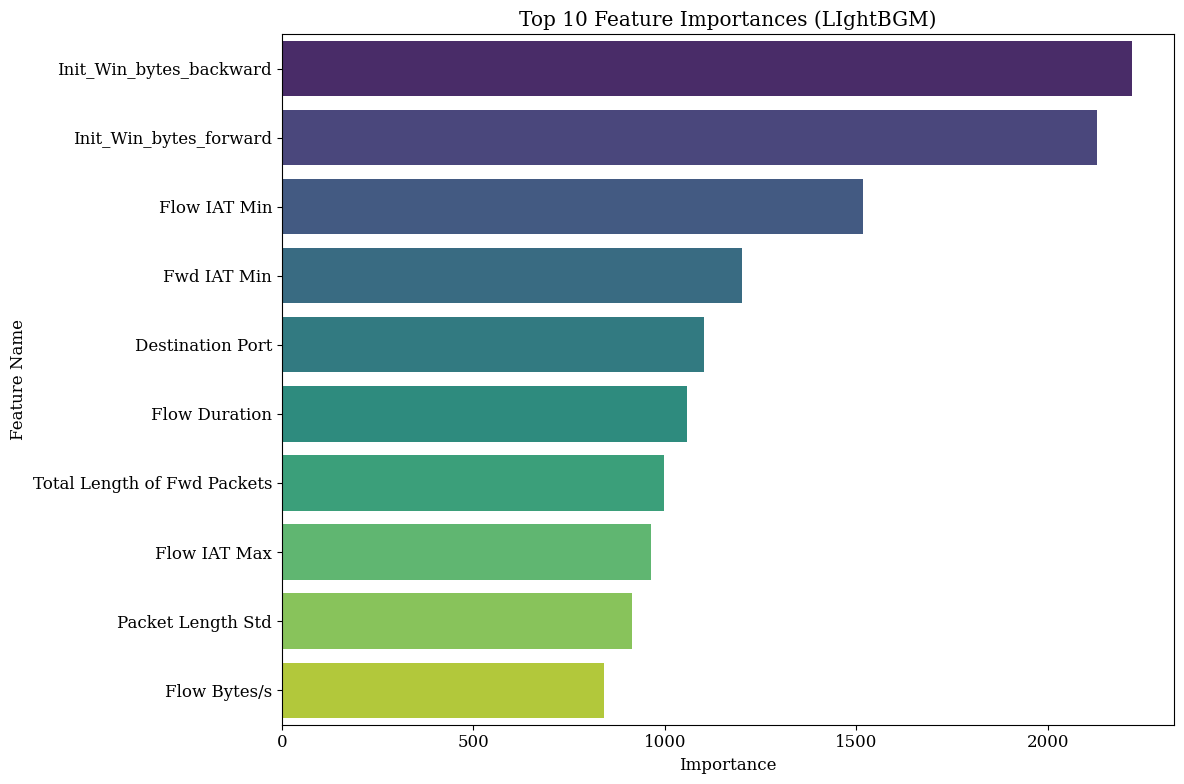

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (LIghtBGM)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

## **Stacking classifier**

In [ ]:
pip install catboost

Training Stacking Classifier...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 244259, number of negative: 30164
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010134 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2482
[LightGBM] [Info] Number of data points in the train set: 274423, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890082 -> initscore=2.091580
[LightGBM] [Info] Start training from score 2.091580
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 219833, number of negative: 27147
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037645 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Accuracy: 0.78155
F1 Score: 0.81738
Precision: 0.89169
Recall: 0.78155


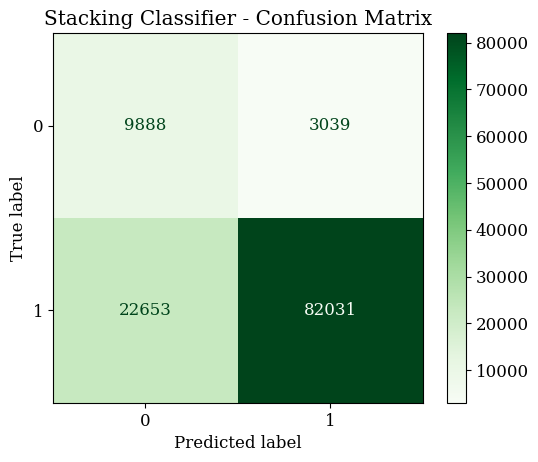


Classification Report:
              precision    recall  f1-score   support

           0    0.30386   0.76491   0.43494     12927
           1    0.96428   0.78361   0.86460    104684

    accuracy                        0.78155    117611
   macro avg    0.63407   0.77426   0.64977    117611
weighted avg    0.89169   0.78155   0.81738    117611



In [ ]:
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler



# 1. Feature Selection
X_train_sel = X_train[top_25_features]
X_test_sel = X_test[top_25_features]

# 2. Define Base Models with balancing parameters
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('lgbm', LGBMClassifier(n_estimators=100, is_unbalance=True, random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(n_estimators=100, scale_pos_weight=0.123, eval_metric='mlogloss', random_state=42, n_jobs=-1)),
    ('et', ExtraTreesClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('cat', CatBoostClassifier(iterations=100, auto_class_weights='Balanced', verbose=False, random_state=42)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
]



# 3. Define Meta-Classifier (Final estimator)
meta_model = LGBMClassifier(n_estimators=50, random_state=42,is_unbalance=True)

# 4. Initialize Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=10,
    stack_method='predict_proba', # Uses probabilities from base models
    passthrough=True,             # Passes original features to the meta-model
    n_jobs=1
)

# 5. Training and Prediction
print("Training Stacking Classifier...")
stacking_clf.fit(X_train_sel, y_train)
y_pred = stacking_clf.predict(X_test_sel)

# 6. Evaluation and Visualization
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.5f}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.5f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.5f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.5f}")

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Greens')
plt.title("Stacking Classifier - Confusion Matrix")
plt.show()

# Print Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=5))


Starting Stacking Classifier...
Training Stacking Classifier...
[LightGBM] [Info] Number of positive: 244259, number of negative: 30164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022882 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 274423, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.890082 -> initscore=2.091580
[LightGBM] [Info] Start training from score 2.091580
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Stacking Classifier Accuracy:  0.91704
Stacking Classifier Precision: 0.91027
Stacking Classifier Recall:    0.91704
Stacking Classifier F1 Score:  0.89998


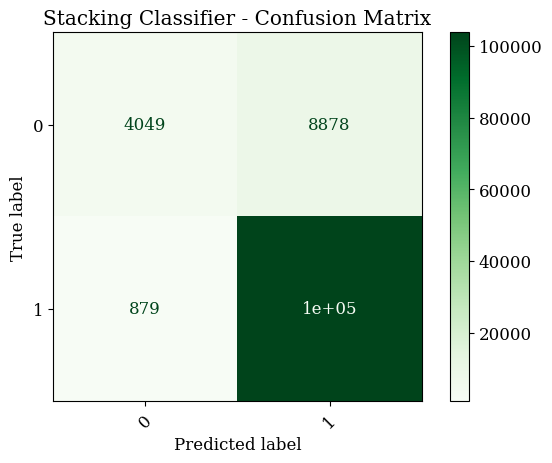

Stacking Classifier Classification Report:
              precision    recall  f1-score   support

           0    0.82163   0.31322   0.45354     12927
           1    0.92121   0.99160   0.95511    104684

    accuracy                        0.91704    117611
   macro avg    0.87142   0.65241   0.70433    117611
weighted avg    0.91027   0.91704   0.89998    117611



In [ ]:
!pip install catboost
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

print("Starting Stacking Classifier...")
X_train_sel = X_train[top_25_features]
X_test_sel = X_test[top_25_features]

# Placeholder models if not already defined (will be overwritten if defined)
try:
    _ = best_rf_model
    _ = best_lgbm_model
    _ = best_xgb_model
    _ = best_et_model
    _ = best_catboost_model
except NameError:
    print("Warning: Tuned base models not found. Using default initialized models for StackingClassifier.")
    best_rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    best_lgbm_model = LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    best_xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
    best_et_model = ExtraTreesClassifier(n_estimators=300, max_depth=None, min_samples_split=5, min_samples_leaf=2, class_weight='balanced', random_state=42, n_jobs=-1)
    best_catboost_model = CatBoostClassifier(iterations=100, random_state=42, verbose=False)

estinators = [
    ('rf', best_rf_model),
    ('lgbm', best_lgbm_model),
    ('xgb', best_xgb_model),
    ('et', best_et_model),
    ('cat', best_catboost_model)
]




meta_classifier = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Initialize the Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=estinators,
    final_estimator=meta_classifier,
    cv=5,
    n_jobs=-1
)

print("Training Stacking Classifier...")
# Train the Stacking Classifier
stacking_clf.fit(X_train_sel, y_train)
print("Stacking Classifier training complete.")


# Predict on Test Set
y_pred_stacking = stacking_clf.predict(X_test_sel)

# Evaluation Metrics
accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
precision_stacking = precision_score(y_test, y_pred_stacking, average='weighted', zero_division=0)
recall_stacking = recall_score(y_test, y_pred_stacking, average='weighted', zero_division=0)
f1_stacking = f1_score(y_test, y_pred_stacking, average='weighted', zero_division=0)

# Print Basic Metrics (5-digit precision)
print(f"\nStacking Classifier Accuracy:  {accuracy_stacking:.5f}")
print(f"Stacking Classifier Precision: {precision_stacking:.5f}")
print(f"Stacking Classifier Recall:    {recall_stacking:.5f}")
print(f"Stacking Classifier F1 Score:  {f1_stacking:.5f}")

# Confusion Matrix
cm_stacking = confusion_matrix(y_test, y_pred_stacking)
ConfusionMatrixDisplay(cm_stacking, display_labels=stacking_clf.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Stacking Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report (5-digit precision)
print("Stacking Classifier Classification Report:")
print(classification_report(y_test, y_pred_stacking, zero_division=0, digits=5))


# **Thank you !**